# Short-Term Stock Price Prediction

This notebook demonstrates how to fetch historical stock data with `yfinance`, prepare features, train regression models, and visualize actual vs predicted next-day closing prices.

## 1. Setup and Dependencies

Install required libraries and import the packages used for data loading, preprocessing, modeling, and visualization.

In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Fetch Historical Stock Data

Load daily stock data for a selected ticker from Yahoo Finance. The example uses Apple (`AAPL`), but you can choose any liquid stock symbol.

In [12]:
ticker = 'AAPL'
stock = yf.Ticker(ticker)
history = stock.history(period='5y', interval='1d')
history = history[['Open', 'High', 'Low', 'Close', 'Volume']]
history.head()

,Open,High,Low,Close,Volume
Date,,,,,
2021-04-19 00:00:00-04:00,130.038141,131.947179,129.872564,131.333557,94264200
2021-04-20 00:00:00-04:00,131.508895,132.005627,128.382362,129.648560,94812300
2021-04-21 00:00:00-04:00,128.918073,130.271926,127.885640,130.028427,68847100
2021-04-22 00:00:00-04:00,129.580358,130.661494,127.992756,128.508972,84566500
2021-04-23 00:00:00-04:00,128.723223,131.606241,128.723223,130.827057,78657500


## 3. Prepare Features and Target

Use the current day's `Open`, `High`, `Low`, and `Volume` values to predict the next day's closing price. This is done by shifting the `Close` column up by one day.

In [13]:
df = history.copy()
df['Next_Close'] = df['Close'].shift(-1)
df = df.dropna()
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Next_Close']
print('Dataset shape:', X.shape)
print('Date range:', df.index.min().date(), 'to', df.index.max().date())
df.head()

Dataset shape: (1255, 4)
Date range: 2021-04-19 to 2026-04-16


,Open,High,Low,Close,Volume,Next_Close
Date,,,,,,
2021-04-19 00:00:00-04:00,130.038141,131.947179,129.872564,131.333557,94264200,129.648560
2021-04-20 00:00:00-04:00,131.508895,132.005627,128.382362,129.648560,94812300,130.028427
2021-04-21 00:00:00-04:00,128.918073,130.271926,127.885640,130.028427,68847100,128.508972
2021-04-22 00:00:00-04:00,129.580358,130.661494,127.992756,128.508972,84566500,130.827057
2021-04-23 00:00:00-04:00,128.723223,131.606241,128.723223,130.827057,78657500,131.216690


## 4. Train/Test Split

Split the data sequentially to preserve temporal order. The earliest 80% of observations are used for training and the latest 20% for validation.

In [14]:
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (1004, 4) Test shape: (251, 4)


## 5. Scale Numeric Features

Standardize features before training to improve model stability and convergence.

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Train Regression Models

Train both a Linear Regression model and a Random Forest regressor to compare short-term forecasting performance.

In [16]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    results[name] = {
        'model': model,
        'predictions': preds,
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
    }
results

{'Linear Regression': {'model': LinearRegression(),
  'predictions': array([194.55088669, 195.48597815, 190.22182115, 199.52762364,
         204.14044776, 205.59538648, 208.11439329, 208.32577146,
         210.43009335, 209.64691138, 212.31278384, 202.50239297,
         199.03246366, 198.40614682, 193.74508433, 196.34586488,
         198.35506954, 207.11783013, 210.99066292, 211.50937595,
         210.81350244, 209.79595758, 205.63973809, 205.63919021,
         202.42702292, 201.00191023, 196.03905988, 198.98296701,
         201.2279429 , 199.12431848, 198.68481772, 201.18094245,
         202.43605913, 204.36855806, 201.20967368, 203.83557642,
         201.44423508, 202.97293255, 199.57350224, 197.70568258,
         196.46921835, 197.35542924, 196.11389937, 196.07584875,
         199.07017885, 199.44978874, 200.7782377 , 202.06338269,
         200.26811479, 200.75157291, 203.22504647, 208.26411456,
         211.0631969 , 213.30897118, 211.70176154, 209.25931605,
         208.49294187, 

## 7. Evaluate and Visualize Predictions

Compare actual next-day closing prices with model predictions on the test period.

In [17]:
eval_df = pd.DataFrame({
    'Date': X_test.index,
    'Actual_Close': y_test.values,
    'LinearPred': results['Linear Regression']['predictions'],
    'ForestPred': results['Random Forest']['predictions'],
})
eval_df = eval_df.set_index('Date')
eval_df.head()

,Actual_Close,LinearPred,ForestPred
Date,,,
2025-04-16 00:00:00-04:00,196.125198,194.550887,195.642994
2025-04-17 00:00:00-04:00,192.321777,195.485978,194.344825
2025-04-21 00:00:00-04:00,198.873245,190.221821,190.191538
2025-04-22 00:00:00-04:00,203.712128,199.527624,193.479628
2025-04-23 00:00:00-04:00,207.465775,204.140448,197.233573


In [18]:
for name, data in results.items():
    print(f'{name}: RMSE={data["rmse"]:.2f}, R2={data["r2"]:.4f}')

Linear Regression: RMSE=3.96, R2=0.9795
Random Forest: RMSE=10.76, R2=0.8482


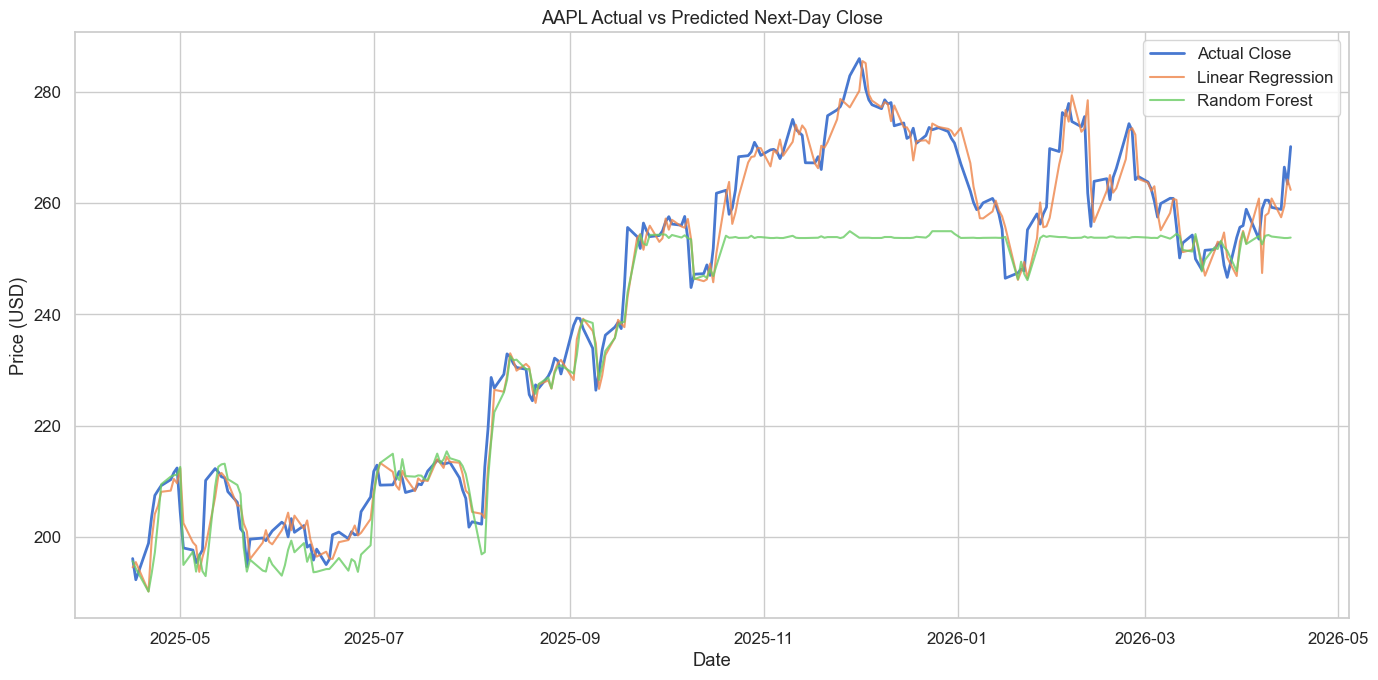

In [19]:
plt.figure(figsize=(14,7))
plt.plot(eval_df.index, eval_df['Actual_Close'], label='Actual Close', linewidth=2)
plt.plot(eval_df.index, eval_df['LinearPred'], label='Linear Regression', alpha=0.8)
plt.plot(eval_df.index, eval_df['ForestPred'], label='Random Forest', alpha=0.8)
plt.title(f'{ticker} Actual vs Predicted Next-Day Close')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Conclusion and Recommendations

- This notebook predicts the next day's closing price from daily `Open`, `High`, `Low`, and `Volume`.
- `Random Forest` typically captures nonlinear patterns better than linear regression for this dataset.
- Further improvements include adding lag features, technical indicators, cross-validation, and advanced time-series models such as XGBoost or LSTM.